In [1]:
## Iteration 1

import tkinter as tk
from tkinter import ttk
from tkinter import messagebox
import threading
import time

# Simulate trial progress
def run_trial(progress_bar):
    for i in range(101):
        time.sleep(0.05)  # Simulated delay
        progress_bar['value'] = i

# Handle trial start
def start_trial():
    name = name_entry.get()
    age = age_entry.get()
    pid = id_entry.get()

    if not name or not age or not pid:
        messagebox.showwarning("Missing Data", "Please fill out all patient fields.")
        return

    messagebox.showinfo("Trial Started", f"Trial initiated for {name} (ID: {pid})")
    
    # Start progress bar in separate thread
    threading.Thread(target=run_trial, args=(progress_bar,), daemon=True).start()

# --- GUI Setup ---
root = tk.Tk()
root.title("Patient Trial Interface")
root.geometry("400x300")

# Patient info
tk.Label(root, text="Patient Name:").pack(pady=(10, 0))
name_entry = tk.Entry(root, width=40)
name_entry.pack()

tk.Label(root, text="Age:").pack()
age_entry = tk.Entry(root, width=40)
age_entry.pack()

tk.Label(root, text="Patient ID:").pack()
id_entry = tk.Entry(root, width=40)
id_entry.pack()

# Trial button
start_button = tk.Button(root, text="Start Trial", command=start_trial)
start_button.pack(pady=20)

# Progress bar
progress_bar = ttk.Progressbar(root, length=300, mode='determinate')
progress_bar.pack(pady=10)

# Run GUI
root.mainloop()


In [ ]:
# Iteration 2

import tkinter as tk
from tkinter import ttk, messagebox
from PIL import Image, ImageTk
import threading
import time
from datetime import date

def run_trial(progress_bar):
    for i in range(101):
        time.sleep(0.05)
        progress_bar['value'] = i

def start_trial():
    name = name_entry.get()
    age = age_entry.get()
    pid = id_entry.get()
    certainty = certainty_var.get()

    if not name or not age or not pid:
        messagebox.showwarning("Missing Data", "Please fill out all patient fields.")
        return

    if certainty == 0:
        messagebox.showwarning("Missing Selection", "Please select certainty level.")
        return

    messagebox.showinfo("Trial Started", f"Starting trial for {name} (ID: {pid}) with certainty {certainty}/10")
    threading.Thread(target=run_trial, args=(progress_bar,), daemon=True).start()

def on_stim_site_click(event):
    x, y = event.x, event.y
    messagebox.showinfo("Stim Site Selected", f"Selected location at x={x}, y={y}")

# --- GUI Setup ---
root = tk.Tk()
root.title("Patient Trial Interface")
root.geometry("600x700")

# # --- Patient Info ---
# tk.Label(root, text="Patient Name:").pack()
# name_entry = tk.Entry(root, width=40)
# name_entry.pack()

# tk.Label(root, text="Age:").pack()
# age_entry = tk.Entry(root, width=40)
# age_entry.pack()

tk.Label(root, text="Patient ID:").pack()
id_entry = tk.Entry(root, width=40)
id_entry.pack()

# --- Date & Tester Info ---
tk.Label(root, text="Date (YYYY-MM-DD):").pack()
date_entry = tk.Entry(root, width=40)
date_entry.insert(0, date.today().isoformat())  # Pre-fill with today's date
date_entry.pack()

tk.Label(root, text="Tester Name:").pack()
tester_entry = tk.Entry(root, width=40)
tester_entry.pack()

# --- Certainty Rating ---
tk.Label(root, text="Certainty (1–10):").pack(pady=(10, 0))
certainty_var = tk.IntVar()
certainty_frame = tk.Frame(root)
certainty_frame.pack()
for i in range(1, 11):
    tk.Radiobutton(certainty_frame, text=str(i), variable=certainty_var, value=i).pack(side=tk.LEFT)

# --- Image Section ---
tk.Label(root, text="Select Stimulation Site:").pack(pady=(20, 5))
try:
    image = Image.open("back_image.png").resize((300, 400))
    photo = ImageTk.PhotoImage(image)
    canvas = tk.Canvas(root, width=300, height=400)
    canvas.create_image(0, 0, anchor=tk.NW, image=photo)
    canvas.pack()
    canvas.bind("<Button-1>", on_stim_site_click)
except Exception as e:
    tk.Label(root, text=f"[Image failed to load: {e}]").pack()

# # --- Trial Button & Progress ---
# start_button = tk.Button(root, text="Start Trial", command=start_trial)
# start_button.pack(pady=20)

button_frame = tk.Frame(root)
button_frame.pack(pady=10)

start_button = tk.Button(button_frame, text="Start Trial", command=start_trial)
start_button.pack(side=tk.LEFT, padx=5)

continue_button = tk.Button(button_frame, text="Continue", command=lambda: print("Continue pressed"))
continue_button.pack(side=tk.LEFT, padx=5)

end_button = tk.Button(button_frame, text="End", command=lambda: print("End pressed"))
end_button.pack(side=tk.LEFT, padx=5)


# --- Progress Bar with Label ---
tk.Label(root, text="Progress:").pack()

progress_bar = ttk.Progressbar(root, length=500, mode='determinate')
progress_bar.pack(pady=10)
progress_bar['value'] = 50  # Set to 50% for demonstration

# --- Run GUI ---
root.mainloop()


In [ ]:
import os
os.chdir()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# Load
# -----------------------
df = pd.read_csv(r"C:\Users\pc\Dropbox\School\UBC\Co-op\ICORD\Kramer-Lab---Modelling-Sham-tcSCS\Data\current_in_the_cord.csv")

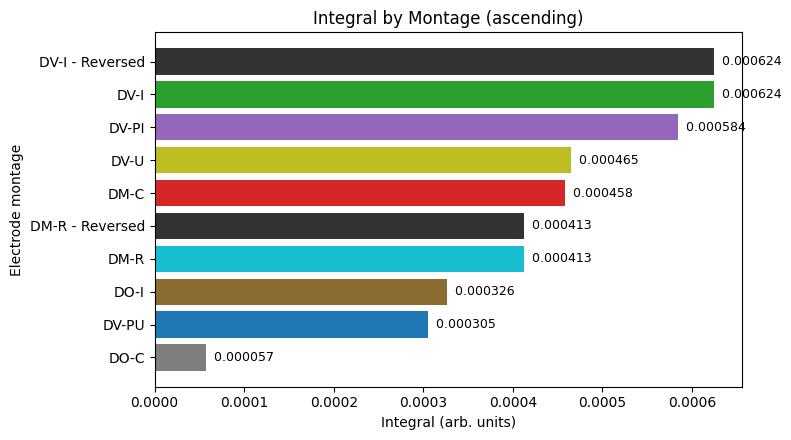

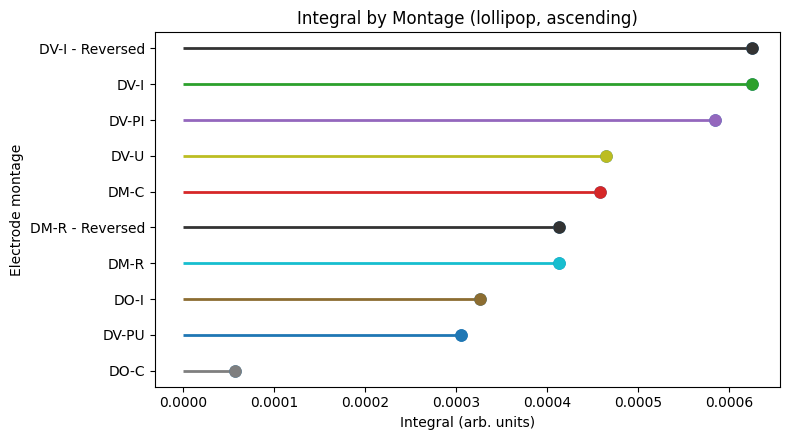

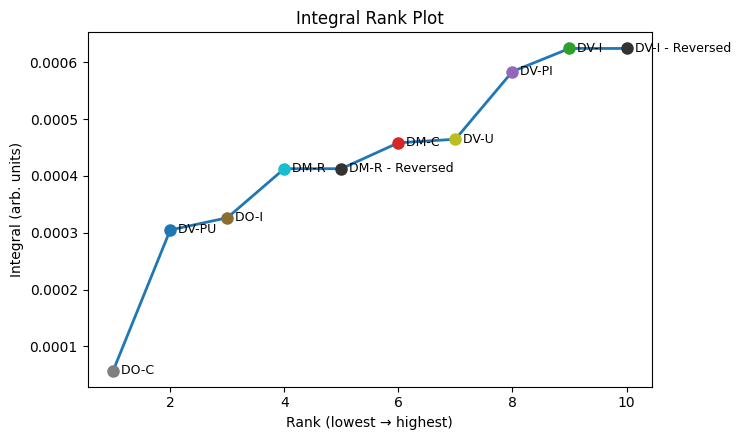

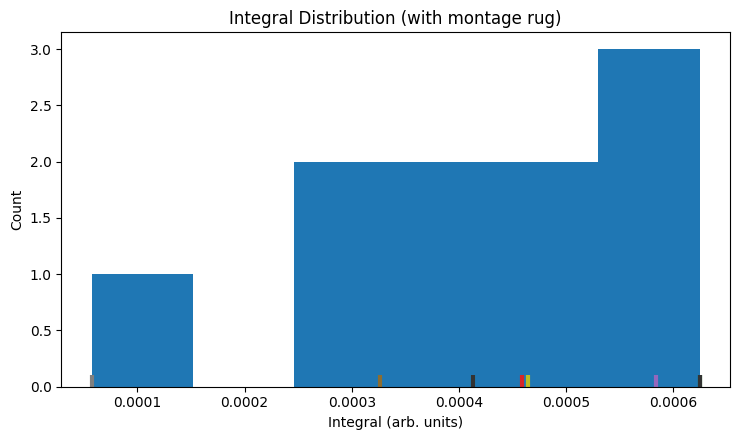

In [2]:

required = {"Name", "Integral"}
missing = required - set(df.columns)
if missing:
    raise KeyError(f"Missing required columns: {missing}. Found: {list(df.columns)}")

# Sort by Integral (ascending)
df_sorted = df.sort_values("Integral", ascending=True).reset_index(drop=True)

# -----------------------
# Color mapping (matched to your boxplot scheme)
# Adjust hex codes if you want them *exactly* identical.
# -----------------------
palette = {
    "DV-I":  "#2ca02c",  # green
    "DV-U":  "#bcbd22",  # olive/yellow-green
    "DV-PI": "#9467bd",  # purple
    "DV-PU": "#1f77b4",  # blue
    "DO-I":  "#8c6d31",  # brown
    "DM-R":  "#17becf",  # cyan
    "DM-C":  "#d62728",  # red
    "DO-C":  "#7f7f7f",  # gray
    "DM-R - q": "#0e8a8a",  # teal (approx)
    "DV-I - q": "#1b7f1b",  # darker green (approx)
}

# Fallback color if a montage name isn't in palette
fallback_color = "#333333"
colors = [palette.get(name, fallback_color) for name in df_sorted["Name"]]

# Optional: nicer numeric labels
def fmt(x):
    # change precision if you want; integral values here are ~1e-4
    return f"{x:.6f}"

# -----------------------
# FIGURE 1: Sorted horizontal bar chart (recommended)
# -----------------------
plt.figure(figsize=(8, 4.5))
plt.barh(df_sorted["Name"], df_sorted["Integral"], color=colors)
plt.xlabel("Integral (arb. units)")
plt.ylabel("Electrode montage")
plt.title("Integral by Montage (ascending)")

# Label each bar
for i, val in enumerate(df_sorted["Integral"]):
    plt.text(val, i, "  " + fmt(val), va="center", ha="left", fontsize=9)

plt.tight_layout()
plt.show()

# -----------------------
# FIGURE 2: Lollipop plot (clean + compact)
# -----------------------
plt.figure(figsize=(8, 4.5))
y = range(len(df_sorted))
plt.hlines(y=y, xmin=0, xmax=df_sorted["Integral"], color=colors, linewidth=2)
plt.plot(df_sorted["Integral"], y, "o", markersize=8)

# Color each dot to match montage
for xi, yi, c in zip(df_sorted["Integral"], y, colors):
    plt.plot([xi], [yi], "o", color=c, markersize=8)

plt.yticks(y, df_sorted["Name"])
plt.xlabel("Integral (arb. units)")
plt.ylabel("Electrode montage")
plt.title("Integral by Montage (lollipop, ascending)")
plt.tight_layout()
plt.show()

# -----------------------
# FIGURE 3: Rank plot (shows spacing nicely)
# -----------------------
plt.figure(figsize=(7.5, 4.5))
x = range(1, len(df_sorted) + 1)  # rank 1..N
plt.plot(x, df_sorted["Integral"], marker="o", linewidth=2)

# color points individually
for xi, yi, c, label in zip(x, df_sorted["Integral"], colors, df_sorted["Name"]):
    plt.plot([xi], [yi], "o", color=c, markersize=8)
    plt.text(xi, yi, f"  {label}", va="center", ha="left", fontsize=9)

plt.xlabel("Rank (lowest → highest)")
plt.ylabel("Integral (arb. units)")
plt.title("Integral Rank Plot")
plt.tight_layout()
plt.show()

# -----------------------
# FIGURE 4: Histogram + colored rug (optional)
# -----------------------
plt.figure(figsize=(7.5, 4.5))
plt.hist(df_sorted["Integral"], bins=6)
plt.xlabel("Integral (arb. units)")
plt.ylabel("Count")
plt.title("Integral Distribution (with montage rug)")

# Rug plot: montage positions along x-axis
y0 = -0.05 * plt.ylim()[1]
for val, c, name in zip(df_sorted["Integral"], colors, df_sorted["Name"]):
    plt.plot([val], [0], marker="|", color=c, markersize=18, markeredgewidth=3)
    # optional tiny labels (can clutter)
    # plt.text(val, 0.02*plt.ylim()[1], name, rotation=90, ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


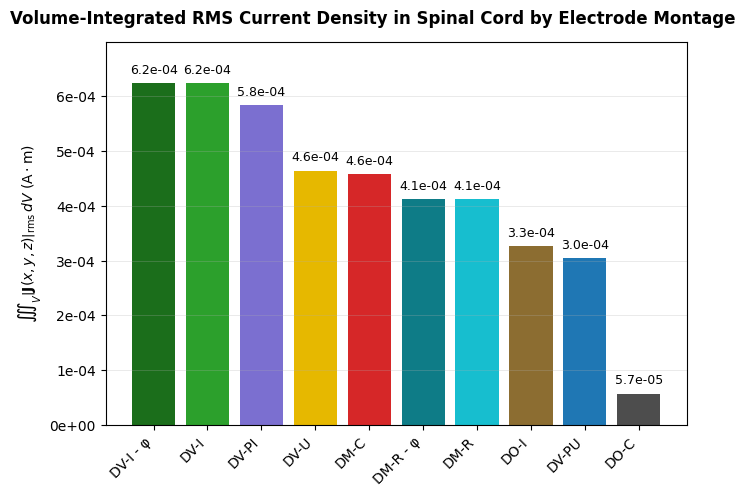

In [16]:
import re
# import pandas as pd
# import matplotlib.pyplot as plt

# # -----------------------
# # Load
# # -----------------------
# df = pd.read_csv(r"/mnt/data/current_in_the_cord.csv")

required = {"Name", "Integral"}
missing = required - set(df.columns)
if missing:
    raise KeyError(f"Missing required columns: {missing}. Found: {list(df.columns)}")

# -----------------------
# Clean montage labels:
#   "(Reversed)" -> "(±)"
# -----------------------
def clean_name(s: str) -> str:
    s = str(s)
    # Match either "(Reversed)" OR "- Reversed" / " - Reversed" at the end
    s = re.sub(r"\s*(?:\(\s*Reversed\s*\)|-\s*Reversed)\s*$", " - φ", s, flags=re.IGNORECASE)
    return s


df["Name_clean"] = df["Name"].map(clean_name)

# Sort ascending by Integral
df_sorted = df.sort_values("Integral", ascending=False).reset_index(drop=True)

# -----------------------
# Color mapping (matched to your earlier palette)
# If your names contain extra suffixes like "(±)", colors are assigned by base montage.
# -----------------------
# palette = {
#     "DV-I":  "#2ca02c",  # green
#     "DV-U":  "#bcbd22",  # olive/yellow-green
#     "DV-PI": "#9467bd",  # purple
#     "DV-PU": "#1f77b4",  # blue
#     "DO-I":  "#8c6d31",  # brown
#     "DM-R":  "#17becf",  # cyan
#     "DM-C":  "#d62728",  # red
#     "DO-C":  "#7f7f7f",  # gray
#     # optional distinct tones for special variants if you use them
#     "DM-R - q": "#0e8a8a",
#     "DV-I - q": "#1b7f1b",
# }
# fallback_color = "#333333"

palette = {
    # DV family
    "DV-U": "#E6B800",
    "DV-I": "#2CA02C",
    "DV-I - φ": "#1B6E1B",
    "DV-PU": "#1F77B4",
    "DV-PI": "#7B6FD0",

    # DM family
    "DM-C": "#D62728",
    "DM-R": "#17BECF",
    "DM-R - φ": "#0E7C87",

    # DO family
    "DO-I": "#8C6D31",
    "DO-C": "#4D4D4D",
}
fallback_color = "#333333"




def base_montage(name: str) -> str:
    """
    Extract a base montage key to map colors robustly.
    Examples:
      'DM-R (±)' -> 'DM-R'
      'DV-I - q' -> 'DV-I - q'
      'DV-PU'    -> 'DV-PU'
    """
    name = name.strip()
    # strip trailing parenthetical like "(±)"
    name = re.sub(r"\s*\(.*?\)\s*$", "", name)
    return name

colors = [palette.get(base_montage(n), fallback_color) for n in df_sorted["Name_clean"]]

# -----------------------
# Plot: Vertical bars, x-axis montages, ascending order
# -----------------------
plt.figure(figsize=(7, 5))
plt.bar(df_sorted["Name_clean"], df_sorted["Integral"], color=colors)

# Y-axis label: triple integral of J(x,y,z) dV with units A·m
# plt.ylabel(r"$\iiint_V \left|\mathbf{J}\right|_{\mathrm{rms}}\, dV\ \mathrm{(A\cdot m)}$")
plt.ylabel(r"$\iiint_V \left|\mathbf{J}(x,y,z)\right|_{\mathrm{rms}}\, dV\ \mathrm{(A\cdot m)}$")



# plt.xlabel("Electrode montage")
# plt.title("Integrated Current Density in Spinal Cord by Electrode Montage")


# Rotate x labels 45°
plt.xticks(rotation=45, ha="right")


# Optional: value labels above bars (use scientific notation if tiny)
def fmt_val(x):
    # tweak if you prefer fixed decimals
    return f"{x:.1e}" if abs(x) < 1e-3 else f"{x:.6f}"

ymax = df_sorted["Integral"].max()
for i, val in enumerate(df_sorted["Integral"]):
    plt.text(i, val + 0.02 * ymax, fmt_val(val), ha="center", va="bottom", fontsize=9)

from matplotlib.ticker import FuncFormatter

ax = plt.gca()
ax.set_ylim(0, df_sorted["Integral"].max() * 1.12)  # 12% headroom (tune 1.08–1.20)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0e}"))
ax.yaxis.get_offset_text().set_visible(False)
# ax.minorticks_on()  # enables minor ticks (needed for minor gridlines)
# ax.grid(True, which="minor", axis="y", linestyle=":", linewidth=0.6, alpha=0.6)
ax.grid(True, which="major", axis="y", linestyle="-", linewidth=0.6, alpha=0.3)


fig = plt.gcf()  # get current figure

fig.text(
    0.53, 0.985, "Volume-Integrated RMS Current Density in Spinal Cord by Electrode Montage",
    ha="center", va="top",
    fontsize=12, fontweight="bold"
)



plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()


In [17]:
fig.savefig(
    "Current_density_integral_barchart_new.png",
    dpi=300,
    bbox_inches="tight"
)

In [13]:
import os
os.chdir(r"C:\Users\pc\Dropbox\School\UBC\Co-op\ICORD\Kramer-Lab---Modelling-Sham-tcSCS\Figures")

In [ ]:
print(hello)